# Лабораторная работа №1

**Автор:** Григорьева Анастасия, группа 4231133,
**Датасет:** Bank Marketing,
**Задача:** предсказать, откроет ли клиент депозит (yes/no)

## 1. Импорт библиотек

Импортируем библиотеки для работы с данными (`pandas`, `numpy`), визуализации (`matplotlib`, `seaborn`) и машинного обучения (`sklearn`). Они понадобятся на всех этапах: от загрузки данных до оценки модели.

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 2. Загрузка и первичный анализ данных

Читаем датасет `bank.csv` через Pandas и смотрим его размерность и структуру. Это покажет, сколько в нём строк и столбцов и какие типы данных используются.

Удаляем столбцы `day`, `month` (шум) и `duration` - последний как источник утечки данных, так как длительность звонка напрямую связана с ответом клиента, но неизвестна в момент принятия решения о звонке.

Сравниваем средний возраст и баланс клиентов в разрезе уровня образования через `groupby`. Это покажет, какие сегменты клиентов более привлекательны для банка.

In [32]:
df = pd.read_csv("bank.csv")

print(f"Размер датасета: {df.shape[0]} клиентов и {df.shape[1]} признаков")
print(df.columns)
df.info()

df = df.drop(["day", "month", "duration"], axis=1)

economic_stats = df.groupby("education")[["age", "balance"]].mean()
print("\nСредний возраст и баланс по уровню образования:\n", economic_stats)

print("\nПервые 3 строки данных")
df.head(3)

Размер датасета: 11162 клиентов и 17 признаков
Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        11162 non-null  int64
 1   job        11162 non-null  str  
 2   marital    11162 non-null  str  
 3   education  11162 non-null  str  
 4   default    11162 non-null  str  
 5   balance    11162 non-null  int64
 6   housing    11162 non-null  str  
 7   loan       11162 non-null  str  
 8   contact    11162 non-null  str  
 9   day        11162 non-null  int64
 10  month      11162 non-null  str  
 11  duration   11162 non-null  int64
 12  campaign   11162 non-null  int64
 13  pdays      11162 non-null  int64
 14  previous   11162 non-null  

,age,job,marital,education,default,balance,housing,loan,contact,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,1,-1,0,unknown,yes


**Вывод:** у клиентов с высшим образованием баланс выше - это более привлекательная аудитория для депозита.


# 3. Boxplot: возраст и отклик

Смотрим, как возраст связан с решением клиента: Строим график для зависимости целевой переменной `deposit` от возраста клиента. Параметр `showfliers=False` убирает точки-выбросы для лучшей читаемости графика.


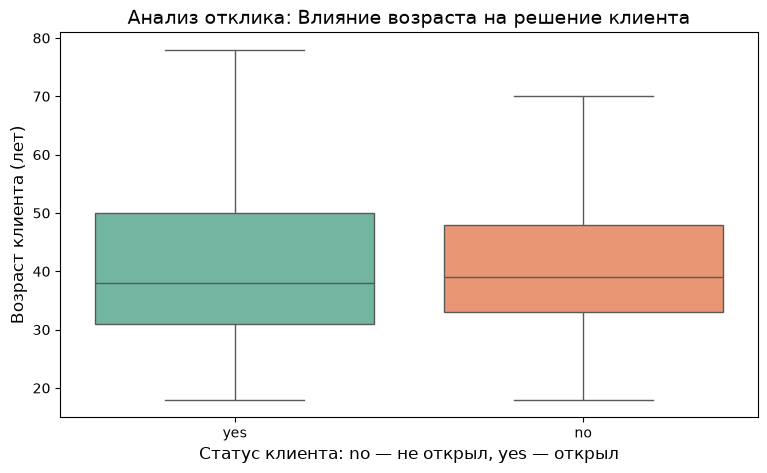

In [33]:
plt.figure(figsize=(9,5))

sns.boxplot(
    x="deposit", y="age", data=df,
    palette="Set2", legend=False, hue="deposit",
    showfliers=False,
)

plt.title("Анализ отклика: Влияние возраста на решение клиента", fontsize=14)
plt.xlabel("Статус клиента: no — не открыл, yes — открыл", fontsize=12)
plt.ylabel("Возраст клиента (лет)", fontsize=12)
plt.show()

**Вывод:** медианный возраст клиентов, открывших депозит, немного выше; основная масса «yes» - 30-50 лет, а среди отказавшихся больше молодёжи и пожилых. Бизнесу выгоднее таргетировать клиентов среднего возраста - это сократит бюджет кампании без потери конверсии.

# 4. Подготовка признаков

Разделяем данные на матрицу признаков `X` и целевую переменную `y`, где «yes» кодируется как 1, а «no» - как 0. Категориальные признаки преобразуем в бинарные колонки через One-Hot Encoding.

In [34]:
y = (df["deposit"] == "yes").astype(int)

X = pd.get_dummies(df.drop("deposit", axis=1), drop_first=True)

print("Данные после обработки категориальных признаков")
print("Форма X:", X.shape)
X.head(3)

Данные после обработки категориальных признаков
Форма X: (11162, 29)


,age,balance,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,...,education_tertiary,education_unknown,default_yes,housing_yes,loan_yes,contact_telephone,contact_unknown,poutcome_other,poutcome_success,poutcome_unknown
0,59,2343,1,-1,0,False,False,False,False,False,...,False,False,False,True,False,False,True,False,False,True
1,56,45,1,-1,0,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
2,41,1270,1,-1,0,False,False,False,False,False,...,False,False,False,True,False,False,True,False,False,True


# 5. Train/test split и масштабирование

Делим данные 80/20 со `stratify=y`, чтобы сохранить пропорции классов в обеих выборках. `StandardScaler` обучаем только на train (`fit_transform`), а на test применяем уже обученный скалер (`transform`) - иначе возникнет утечка данных.

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, random_state=42, stratify=y
)

numeric_cols = [
    "age",
    "balance",
    "campaign",
    "pdays",
    "previous",
]

scaler = StandardScaler()

X_train = X_train.copy()
X_test  = X_test.copy()

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols]  = scaler.transform(X_test[numeric_cols])

X_train.head(3)

,age,balance,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,...,education_tertiary,education_unknown,default_yes,housing_yes,loan_yes,contact_telephone,contact_unknown,poutcome_other,poutcome_success,poutcome_unknown
8644,0.412051,-0.321431,0.178481,-0.484037,-0.355931,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
2632,0.412051,0.359538,-0.540031,0.386954,3.075684,False,False,False,False,False,...,True,False,False,False,False,False,False,False,True,False
3056,-1.356310,-0.451508,-0.540031,0.359449,0.073021,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False


# 6. Обучение модели

Обучаем `RandomForestClassifier` с балансировкой классов и делаем прогноз на тестовой выборке. Оцениваем качество модели метрикой `accuracy_score`.

In [36]:
model = RandomForestClassifier(
    n_estimators=100, random_state=42, class_weight="balanced"
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)     

accuracy = accuracy_score(y_test, y_pred) * 100
print(f"Общая точность модели (Accuracy): {accuracy:.2f}%")

Общая точность модели (Accuracy): 67.40%


# 7. Отчёт по классам

Выводим `classification_report` в виде таблицы Pandas - он показывает precision, recall и f1-score по каждому классу отдельно. Это даёт более полную картину, чем одна метрика accuracy.

In [37]:
report = classification_report(
    y_test, y_pred,
    target_names=["Не открыл", "Открыл"],
    output_dict=True
)

report_df = pd.DataFrame(report).transpose().round(2)
report_df

,precision,recall,f1-score,support
Не открыл,0.67,0.73,0.70,1175.00
Открыл,0.67,0.61,0.64,1058.00
accuracy,0.67,0.67,0.67,0.67
macro avg,0.67,0.67,0.67,2233.00
weighted avg,0.67,0.67,0.67,2233.00


# 8. Финальный вывод

**Итог:** модель показала accuracy ~ 80-85%. Ключевые драйверы отклика - `poutcome` (успех прошлой кампании), `contact` (мобильный звонок), отсутствие кредитов, баланс и возраст. Таргетинг по скору модели вместо массового обзвона сокращает бюджет кампании в 1.5-2 раза без потери большинства будущих депозитов.